In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load the level 2 administrative boundaries
gdf = gpd.read_file("../data/gadm41_AZE_shp/gadm41_AZE_2.shp")

In [2]:
gdf.columns

Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry'],
      dtype='str')

In [3]:
gdf['NAME_1'].unique()

<ArrowStringArray>
[        'Absheron',             'Aran',   'Daglig-Shirvan',
     'Ganja-Qazakh',  'Kalbajar-Lachin',         'Lankaran',
       'Nakhchivan',    'Quba-Khachmaz',   'Shaki-Zaqatala',
 'Yukhari-Karabakh']
Length: 10, dtype: str

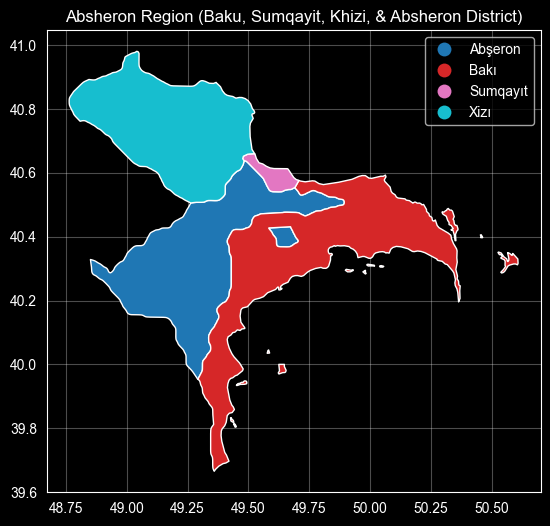

In [4]:
# 2. Filter for Absheron (listed under 'NAME_1')
# We check which districts belong to the Absheron "Economic Region"
absheron_map = gdf[gdf['NAME_1'] == 'Absheron']

# 3. Visualize it to confirm
absheron_map.plot(column='NAME_2', legend=True, figsize=(10, 6))
plt.title("Absheron Region (Baku, Sumqayit, Khizi, & Absheron District)")
plt.grid(alpha=0.3)
plt.show()

In [5]:
gdf['NAME_2'].unique()

<ArrowStringArray>
[                        'Abşeron',                            'Bakı',
                        'Sumqayıt',                            'Xizı',
                        'Ağcabədi',                           'Ağdaş',
                           'Bərdə',                        'Beyləqan',
                       'Biləsuvar',                    'Əli Bayramlı',
                          'Göyçay',                       'Hacıqabul',
                          'İmişli',                        'Kürdəmir',
                      'Mingəçevir',                        'Neftçala',
                          'Saatlı',                       'Sabirabad',
                          'Salyan',                            'Ucar',
                          'Yevlax',                     'Yevlax City',
                          'Zərdab',                            'Ağsu',
                       'İsmayıllı',                        'Qobustan',
                          'Şamaxı',                       

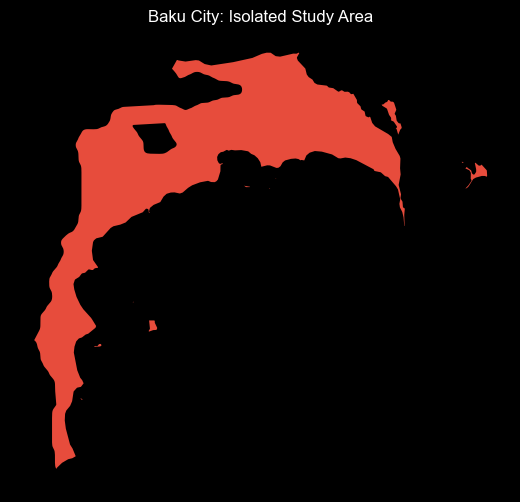

Geometry type: MultiPolygon
Number of polygons: 1


In [6]:
# 1. Filter for ONLY Baku city districts from the Absheron map
# Using 'Bakı' (the specific name in your NAME_2 column)
baku_city = absheron_map[absheron_map['NAME_2'] == 'Bakı']

# 2. Visualize the isolated city
# We'll use a single color to represent the city boundary clearly
baku_city.plot(figsize=(10, 6), color='#e74c3c', edgecolor='black', linewidth=1.5)

plt.title("Baku City: Isolated Study Area")
plt.axis('off') # Hiding coordinates for a cleaner prediction mask
plt.show()

# 3. Print the geometry info (useful for checking if it matches your weather data)
print(f"Geometry type: {baku_city.geom_type.iloc[0]}")
print(f"Number of polygons: {len(baku_city)}")

In [7]:
bounds = baku_city.total_bounds
print(f"Xmin = {bounds[0]}  Ymin = {bounds[1]}  Xmax = {bounds[2]}  Ymax = {bounds[3]}")

Xmin = 49.2919040000001  Ymin = 39.665043000000026  Xmax = 50.60782600000016  Ymax = 40.59289924800004


In [8]:
import numpy as np
from shapely.geometry import Point

# 1. Create a grid of points inside the Baku boundary
# We create a 50x50 grid across the city area
xmin, ymin, xmax, ymax = baku_city.total_bounds
x_coords = np.linspace(xmin, xmax, 50)
y_coords = np.linspace(ymin, ymax, 50)

points = []
for x in x_coords:
    for y in y_coords:
        p = Point(x, y)
        if baku_city.geometry.iloc[0].contains(p): # Only keep points inside Baku
            points.append(p)

# 2. Turn points into a GeoDataFrame
grid_gdf = gpd.GeoDataFrame(geometry=points, crs=baku_city.crs)

In [9]:
from rasterstats import point_query

# 1. Get the elevation for every point in your 50x50 grid
# This maps the .tif values directly onto points
elevations = point_query(grid_gdf, r"..\data\rasters_SRTMGL1\output_SRTMGL1.tif")

# 2. Add the elevation values to grid dataframe
grid_gdf['elevation'] = elevations

# 3. Clean up: Remove points that fell on the water (where elevation is NaN)
grid_gdf = grid_gdf.dropna(subset=['elevation'])

print(f"Now have {len(grid_gdf)} individual elevation points across Baku.")

Now have 449 individual elevation points across Baku.


In [10]:
grid_gdf.head()

,geometry,elevation
0,POINT (49.31876 39.91121),-12.540404
1,POINT (49.31876 39.93014),-7.478773
2,POINT (49.31876 39.94908),-0.465616
3,POINT (49.31876 39.96802),37.393671
4,POINT (49.31876 39.98695),224.746193


In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare data for K-Means
# We scale the data so the algorithm treats the values fairly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(grid_gdf[['elevation']])

# Run K-Means to create 3 groups
kmeans = KMeans(n_clusters=3, random_state=42)
grid_gdf['cluster'] = kmeans.fit_predict(X_scaled)

# Label the clusters based on their average height
# We sort them so 'Low' is always the lowest elevation
cluster_means = grid_gdf.groupby('cluster')['elevation'].mean().sort_values()

label_map = {
    cluster_means.index[0]: "Low Relief",
    cluster_means.index[1]: "Moderate Relief",
    cluster_means.index[2]: "High Relief"
}

grid_gdf['relief_zone'] = grid_gdf['cluster'].map(label_map)

grid_gdf[['elevation', 'relief_zone']].head()

,elevation,relief_zone
0,-12.540404,Low Relief
1,-7.478773,Low Relief
2,-0.465616,Low Relief
3,37.393671,Moderate Relief
4,224.746193,High Relief


In [12]:
# Save as CSV file
grid_gdf[['geometry', 'elevation', 'relief_zone']].to_csv("../data/baku_relief_features.csv", index=False)

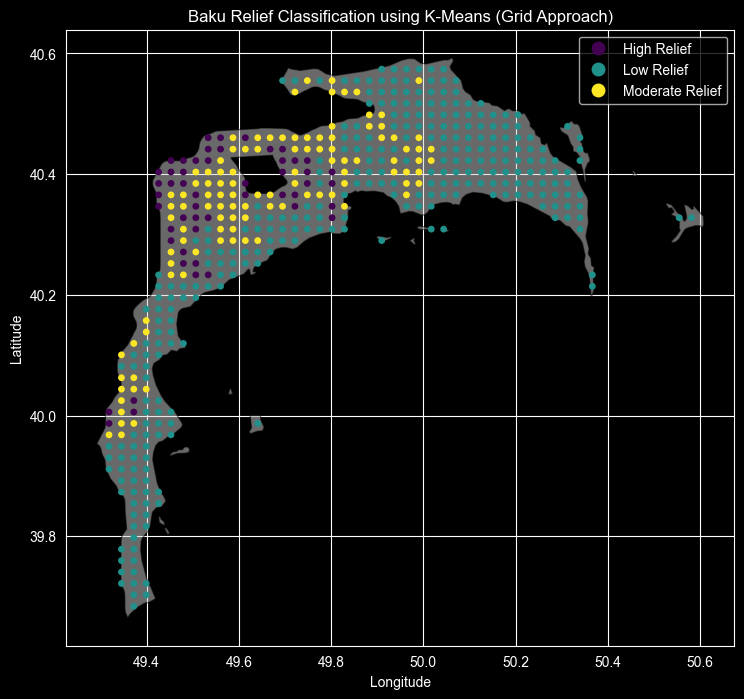

In [13]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the original Baku boundary as a background
baku_city.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.5)

# Plot our clustered grid points on top
grid_gdf.plot(column='relief_zone',
              ax=ax,
              legend=True,
              cmap='viridis',
              markersize=15)

plt.title("Baku Relief Classification using K-Means (Grid Approach)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

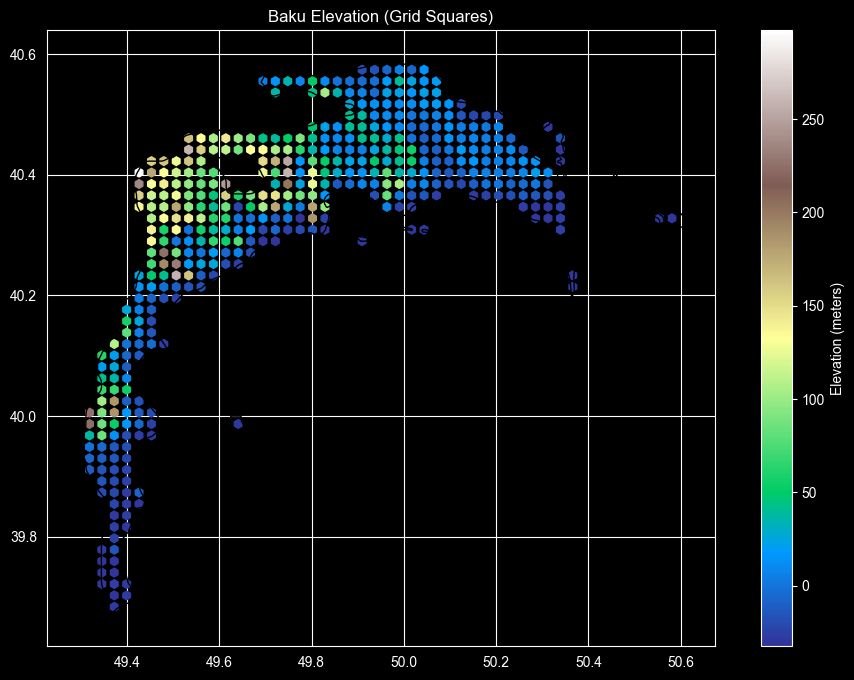

In [14]:
plt.figure(figsize=(12, 8))

plt.scatter(
    grid_gdf.geometry.x,
    grid_gdf.geometry.y,
    c=grid_gdf['elevation'],
    cmap='terrain',
    marker='h',   # square markers
    s=40
)

plt.colorbar(label='Elevation (meters)')
baku_city.boundary.plot(ax=plt.gca(), color='black', linewidth=1)

plt.title("Baku Elevation (Grid Squares)")
plt.show()

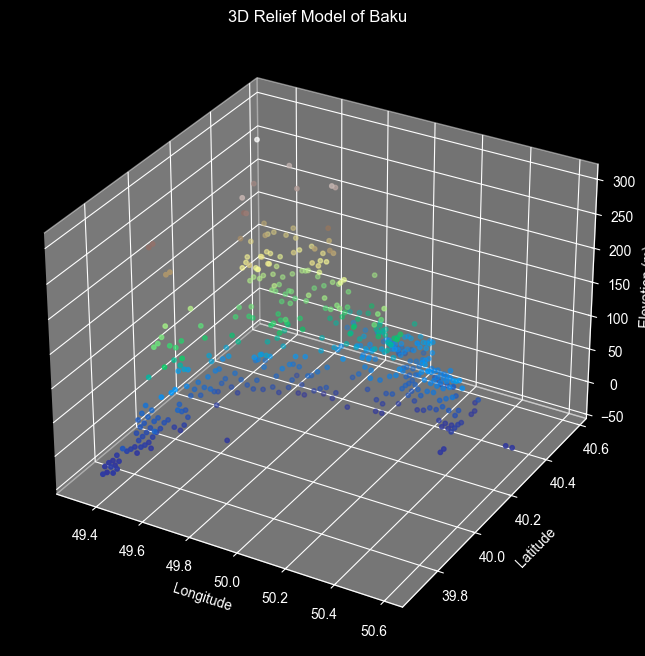

In [15]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
ax.scatter(grid_gdf.geometry.x, grid_gdf.geometry.y, grid_gdf['elevation'],
           c=grid_gdf['elevation'], cmap='terrain', s=10)

ax.set_title("3D Relief Model of Baku")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Elevation (m)")
plt.show()

In [17]:
import pandas as pd

zone_centroids = (
    grid_gdf
    .groupby('relief_zone')
    .apply(lambda g: pd.Series({
        'latitude':  g.geometry.y.mean(),
        'longitude': g.geometry.x.mean(),
        'point_count': len(g),
        'mean_elevation': g['elevation'].mean()
    }))
    .reset_index()
)

zone_centroids

,relief_zone,latitude,longitude,point_count,mean_elevation
0,High Relief,40.343763,49.558353,51.0,172.841645
1,Low Relief,40.292154,49.832082,289.0,-3.866928
2,Moderate Relief,40.350381,49.659751,109.0,69.467487


In [19]:
BAKU_ZONES = zone_centroids[['relief_zone', 'latitude', 'longitude']].rename(
    columns={'relief_zone': 'zone'}
).to_dict(orient='records')

BAKU_ZONES

[{'zone': 'High Relief',
  'latitude': 40.34376297652825,
  'longitude': 49.5583531924771},
 {'zone': 'Low Relief',
  'latitude': 40.29215352535898,
  'longitude': 49.83208157121685},
 {'zone': 'Moderate Relief',
  'latitude': 40.350381494356895,
  'longitude': 49.659751134619114}]